# 0. Подготовка


## Шаг 1. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Шаг 2. Скачивание датасета


Перейдите по ссылке из личного кабинета на Google Таблицу со списком студентов. Найдите свое ФИО в списке и запомните соответствующий порядковый номер. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю.

In [2]:
Student_ID = 36

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [3]:
datasets = [
    (
        'Combined Cycle Power Plant',
        'https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant',
        'PE',
        85, 15
    ),
    (
        'Beijing PM2.5',
        'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data',
        'pm2.5',
        80, 20
    ),
    (
        'Airfoil Self-Noise',
        'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise',
        'scaled-sound-pressure',
        90, 10
    ),
    (
        'Energy Efficiency',
        'https://archive.ics.uci.edu/dataset/242/energy+efficiency',
        'Y1, Y2 (здесь две целевые переменные)',
        90, 10
    ),
    (
        'Bike Sharing',
        'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset',
        'cnt',
        90, 10
    ),
    (
        'Forest Fires',
        'https://archive.ics.uci.edu/dataset/162/forest+fires',
        'area',
        90, 10
    ),
    (
        'Concrete Compressive Strength',
        'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength',
        'Concrete compressive strength',
        90, 10
    )
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")
    print(f"Разделение выборки на train+val/test: {datasets[dataset_id][3]}%/{datasets[dataset_id][4]}")

Информация о датасете 'Beijing PM2.5' доступна по следующей ссылке: https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data
Целевая переменная: pm2.5
Разделение выборки на train+val/test: 80%/20


## Шаг 3. Загрузка и обработка датасета

Считайте датасет в датафрейм и обработайте его.

In [4]:
df = pd.read_csv("beijing+pm2+5+data/PRSA_data_2010.1.1-2014.12.31.csv")

В обработке датасета вы имеете (почти) полную свободу (важно в итоге просто побить бейзлайн).

Что НЕОБХОДИМО сделать:
- обработать пропуски, если есть
- закодировать категориальные фичи

Что ПОЛЕЗНО сделать:
- удалить дубликаты, если есть
- обработать выбросы
- удалить лишние фичи, если есть (возможно, полезно будет посмотреть на корреляции числовых признаков)
- стандартизировать данные, (выход модели необходимо будет привести к исходному масштабу, так что коэффициенты стандартизации нужно запомнить)

ПОДСКАЗКА: https://scikit-learn.org/stable/api/sklearn.preprocessing.html в помощь

ВАЖНО: обработанный по необходимым пунктам датафрейм запишите в переменную `df_base`, обработанный далее по вашему желанию датафрейм запишите в переменную `df_processed`.

НЕ ПЕРЕЗАПИСЫВАЙТЕ ЭТИ ПЕРЕМЕННЫЕ И `df`.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [6]:
df.isna().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [7]:
df_base = df.dropna()
df_base.isna().sum()

No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64

In [8]:
df_base["cbwd"] = df_base["cbwd"].astype("category")
df_base["cbwd"].cat.categories

/tmp/ipykernel_105704/1986576917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base["cbwd"] = df_base["cbwd"].astype("category")


Index(['NE', 'NW', 'SE', 'cv'], dtype='object')

In [9]:
df_base = pd.get_dummies(df_base, dtype=float)

In [10]:
df_base.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,1.79,0,0,0.0,0.0,1.0,0.0
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,2.68,0,0,0.0,0.0,1.0,0.0
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,3.57,0,0,0.0,0.0,1.0,0.0
27,28,2010,1,2,3,181.0,-7,-5.0,1022.0,5.36,1,0,0.0,0.0,1.0,0.0
28,29,2010,1,2,4,138.0,-7,-5.0,1022.0,6.25,2,0,0.0,0.0,1.0,0.0


In [11]:
df_base.duplicated().sum()

0

In [12]:
df_processed = df_base.copy()
len(df_processed.columns)

16

Посмотрим на распределения и обозначим на графиках границы для 98% перцентиля

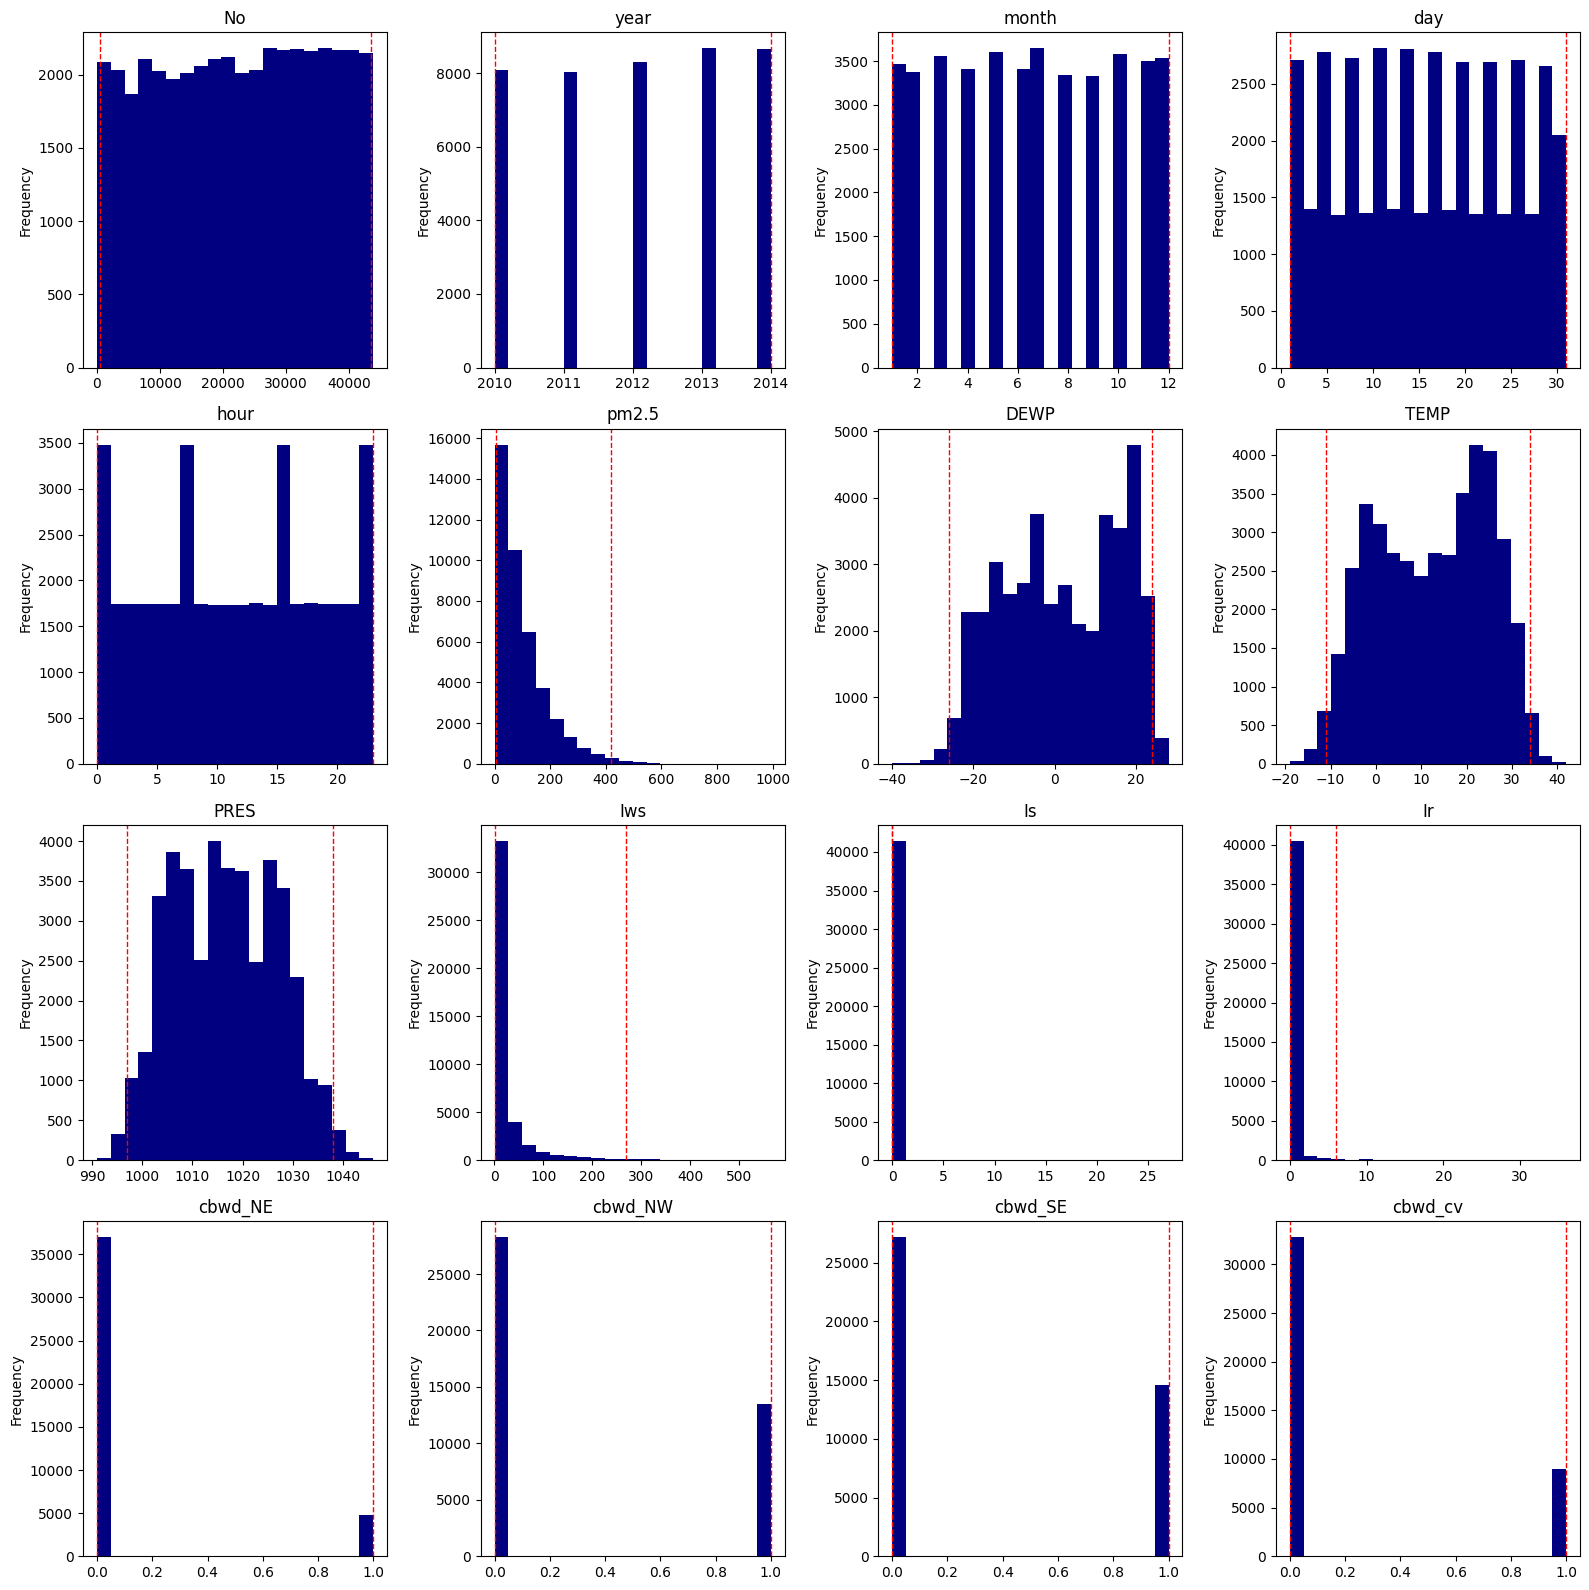

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(df_processed.columns):
    ax = axes[i]
    df_processed[col].plot(kind='hist', bins=20, ax=ax, title=col, color="navy")
    qh = df_processed[col].quantile(0.99)
    ql = df_processed[col].quantile(0.01)
    ax.axvline(qh, color='red', linestyle='--', linewidth=1)
    ax.axvline(ql, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Наблюдаем значительные выбросы в признаках `pm2.5`, `Iws`, `Is`, `Ir`. Обработаем их. как было видно из статистик по стоблцам, у `Is`, `Ir` совпадают `min` с `75%` - похоже, они принимают только одно значение, за исключением выбросов, рассмотрим их отдельно.

In [14]:
df_processed["Is"].quantile(0.995)

4.0

In [15]:
df_processed["Ir"].quantile(0.99)

6.0

In [16]:
outl_features = ["pm2.5", "Iws", "Is", "Ir"]
quantiles = {col: df_processed[col].quantile(0.98) for col in outl_features}
quantiles["Is"] = df_processed["Is"].quantile(0.995)
quantiles["Ir"] = df_processed["Ir"].quantile(0.99)

for col in outl_features:
    df_processed = df_processed[df_processed[col] < quantiles[col]]

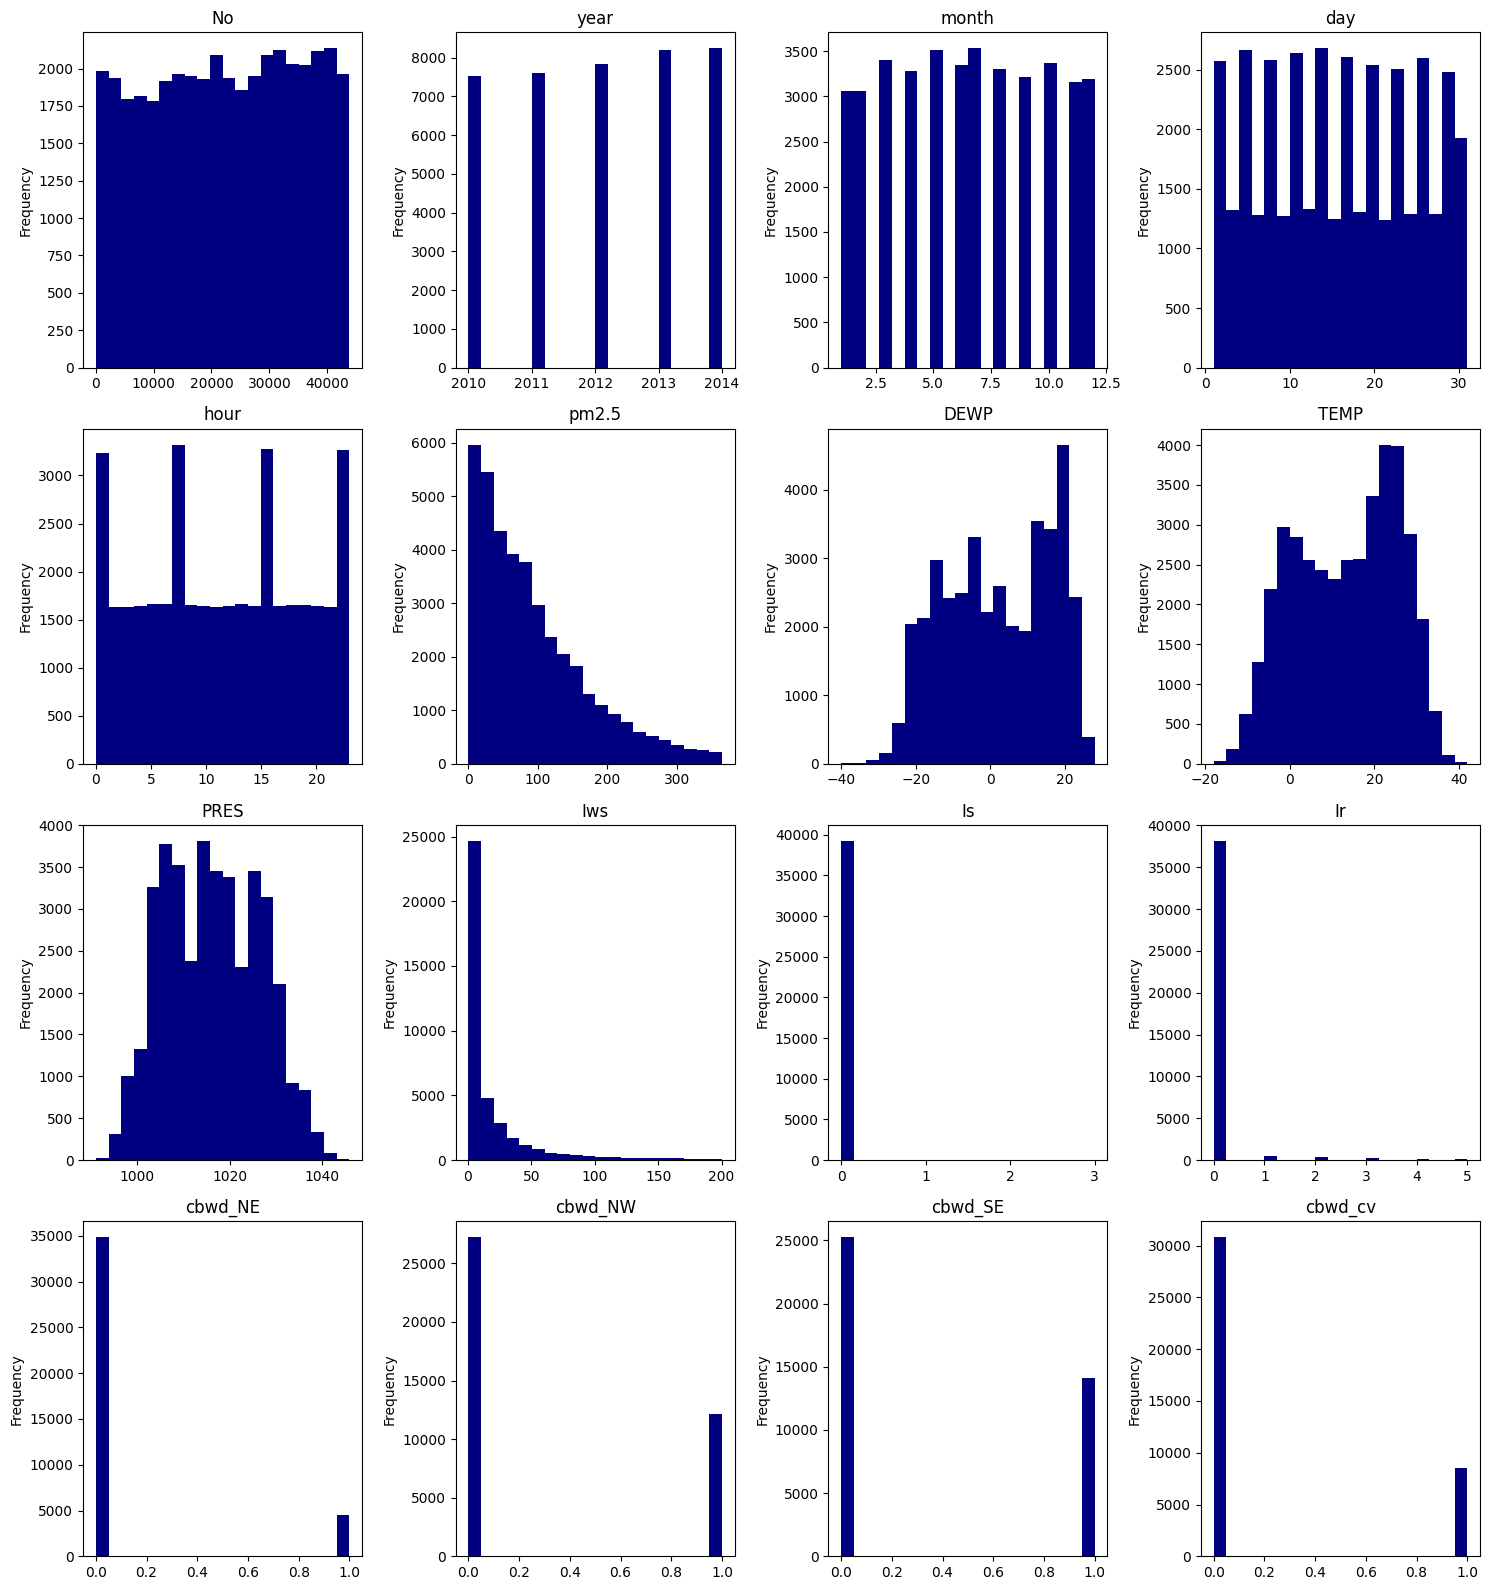

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(df_processed.columns):
    df_processed[col].plot(kind='hist', bins=20, ax=axes[i], title=col, color="navy")

plt.tight_layout()
plt.show()

Посмотрим на корреляцию признаков

<Axes: >

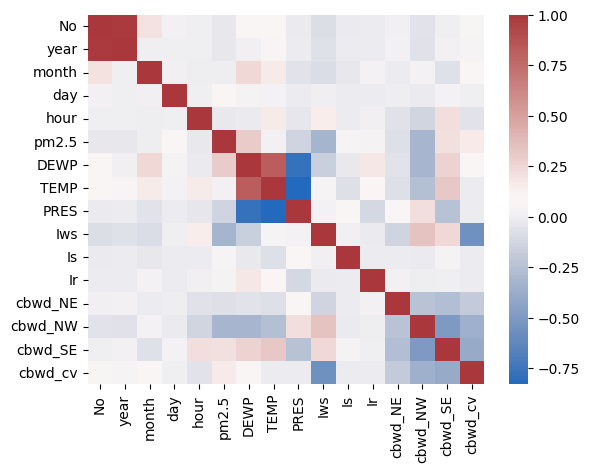

In [18]:
corrs = df_processed.corr(method="spearman")
sns.heatmap(corrs, cmap="vlag")

Наблюдаем почти 100% корреляцию между `year` и `No`, и сильную (около 80%) между `DEWP` и `TEMP`.

In [19]:
df_processed = df_processed.drop(columns="year")

In [20]:
X = df_processed.drop(columns="pm2.5")
y = df_processed["pm2.5"]
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns, index=X.index)
df_processed = pd.concat([X_scaled, y], axis=1)

In [21]:
df_processed.describe().apply(lambda s: s.apply('{0:.5f}'.format))

,No,month,day,hour,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv,pm2.5
count,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000,39406.00000
mean,0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,93.35497
std,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,1.00001,77.94983
min,-1.76451,-1.62321,-1.66709,-1.66521,-2.92136,-2.54050,-2.44986,-0.57696,-0.05447,-0.15561,-0.36076,-0.66790,-0.74822,-0.52714,0.00000
25%,-0.84243,-0.74072,-0.87130,-0.79660,-0.83815,-0.89358,-0.79451,-0.53469,-0.05447,-0.15561,-0.36076,-0.66790,-0.74822,-0.52714,30.00000
50%,0.00947,0.14176,0.03818,-0.07276,-0.00487,0.09458,-0.01553,-0.43597,-0.05447,-0.15561,-0.36076,-0.66790,-0.74822,-0.52714,73.00000
75%,0.86525,0.73008,0.83398,0.79585,0.96730,0.83569,0.76346,0.05767,-0.05447,-0.15561,-0.36076,1.49723,1.33651,-0.52714,134.00000
max,1.69598,1.61256,1.74346,1.66446,1.80058,2.40027,2.90567,5.72776,25.39974,10.86946,2.77192,1.49723,1.33651,1.89702,365.00000


# 1. Линейная регрессия с помощью sklearn

## Шаг 1. Разделение на train/val/test выборки

Разделите датафрейм на фичи и на целевую переменную (в одном из вариантов две целевых переменных)

In [22]:
np.random.seed(73)

In [23]:
X_base, y_base = df_base.drop(columns="pm2.5"), df_base["pm2.5"]
X_processed, y_processed = df_processed.drop(columns="pm2.5"), df_processed["pm2.5"]

Разделите датафреймы `base` и `processed` каждый на выборки train/val/test (запишите их в переменные ниже)

In [24]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2)

In [25]:
X_train_processed, X_test_processed, y_train_processed, y_test_processed = \
    train_test_split(X_processed, y_processed, test_size=0.2)

X_train_processed1, X_val_processed, y_train_processed1, y_val_processed = \
    train_test_split(X_train_processed, y_train_processed, test_size=0.2)

ВАЖНО: размер test-выборки указан в вашем варианте задания (рядом с ссылкой на скачивание датасета)

# Шаг 2. Обучение линейной регрессии

Обучите линейную регресию, используя scikit-learn библиотеку

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

In [27]:
def baseline():
  lin_reg = LinearRegression()
  lin_reg.fit(X_train_base, y_train_base)
  return lin_reg.predict(X_test_base)

In [28]:
y_pred_base = baseline()
print(f"MAPE-метрика на baseline: {mean_absolute_percentage_error(y_test_base, y_pred_base)}")

MAPE-метрика на baseline: 1.3199553997212852


ЗАДАЧА: побить бейзлайн - получить итоговые метрики лучше, чем метрики для `y_pred_base`

Поскольку у обычной реализации линейной регрессии нет гиперпараметров, которые могут сильно повлиять на качество обучения, воспользуемся $L_1$-регуляризацией и проварьируем параметр $\alpha$. Обычно его подбирают по логарифмической шкале.

In [29]:
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV

In [30]:
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
L1_reg = linear_model.Lasso()
grid = GridSearchCV(L1_reg, params, scoring='neg_mean_squared_error')
grid.fit(X_train_processed1, y_train_processed1)
results = pd.DataFrame(grid.cv_results_)
results['MSE'] = -results['mean_test_score']
print(results[['param_alpha', 'MSE']])

   param_alpha          MSE
0         0.01  4364.726009
1         0.10  4364.979059
2         1.00  4392.439039
3        10.00  5621.807007
4       100.00  6114.174631


In [31]:
L1_reg = linear_model.Lasso(alpha=0.01).fit(X_train_processed, y_train_processed)
y_pred_processed = L1_reg.predict(X_test_processed)
print(f"MAPE-метрика на processed: {mean_absolute_percentage_error(y_test_processed, y_pred_processed)}")

MAPE-метрика на processed: 1.197435526371507


# 2. Реализация градиентного спуска с помощью numpy

В рамках этого задания реализуйте собственный стохастический градиентный спуск на numpy.

## Шаг 1. Реализация SGD

In [32]:
class CustomSGD:
  def __init__(self, params1=None, params2=None, batch_size=1, tol=1e-6, epochs=100, lr=0.01, alpha=0.0):
    self.batch_size = batch_size
    self.tol = tol
    self.epochs = epochs
    self.lr = lr
    self.alpha = alpha  
    #params_i - заглушки для прохождения теста, в данной реализации не используются

  def step(self, x_batch, y_batch):
    return # заглушка для теста
  
  def fit(self, X, y):
    N = len(y)
    w = np.random.randn(np.size(X, 1)+1, 1)
    X_b = np.hstack((np.ones((N, 1)), X))

    for epoch in range(self.epochs):
      idxs = np.random.permutation(N)
      X_shuffled = X_b[idxs]
      y_shuffled = y[idxs]

      for i in range(self.batch_size, N, self.batch_size):
        X_batch = X_shuffled[i-self.batch_size:i]
        y_batch = y_shuffled[i-self.batch_size:i]
        
        f = X_batch @ w
        err = f - y_batch
        grad = 2 * X_batch.T @ err / self.batch_size
        grad += 2 * self.alpha * w # +rigde
        w -= self.lr * grad

      mse = np.mean((X_b @ w - y) ** 2)
      if mse < self.tol:
          break
    
    return w

### Метод наименьших квадратов

In [33]:
class LeastSquares:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X_b = np.hstack((np.ones((X.shape[0], 1)), X))
        U, s, Vt = np.linalg.svd(X_b, full_matrices=False)
        
        S = np.diag(s)
        S_inv = np.diag(1.0 / s)
        X_pinv = Vt.T @ S_inv @ U.T
        
        self.w = X_pinv @ y
        return self.w 

In [34]:
class CustomAdam:
    def __init__(self, batch_size=1, tol=1e-6, epochs=100, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, alpha=0.0):
        self.batch_size = batch_size
        self.tol = tol
        self.epochs = epochs
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.alpha = alpha

    def fit(self, X, y):
        N = len(y)
        w = np.random.randn(X.shape[1] + 1, 1)
        X_b = np.hstack((np.ones((N, 1)), X))
        
        s = np.zeros_like(w)
        v = np.zeros_like(w)
        
        for epoch in range(self.epochs):
            idxs = np.random.permutation(N)
            X_shuffled = X_b[idxs]
            y_shuffled = y[idxs]
            
            for i in range(self.batch_size, N, self.batch_size):
                X_batch = X_shuffled[i-self.batch_size:i]
                y_batch = y_shuffled[i-self.batch_size:i].reshape(-1, 1)
                
                f = X_batch @ w
                err = f - y_batch
                grad = 2 * X_batch.T @ err / self.batch_size
                grad += 2 * self.alpha * w
                
                s = self.beta1 * s + (1 - self.beta1) * grad
                v = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
                
                s_hat = s / (1 - self.beta1 ** (epoch + 1))
                v_hat = v / (1 - self.beta2 ** (epoch + 1))
                
                w -= self.lr * s_hat / (np.sqrt(v_hat) + self.eps)
            
            mse = np.mean((X_b @ w - y.reshape(-1, 1)) ** 2)
            if mse < self.tol:
                break
                
        return w

# 3. Реализация линейной регрессии с помощью numpy

## Шаг 1. Реализация линейной регрессии

В рамках этого задания реализуйте класс собственной линейной регресии на numpy

In [35]:
class CustomLinearRegression:
  def __init__(self, solver='SGD', **kwargs):
    self.solver = solver
    self.kwargs = kwargs
    self.model = None
    self.w = None

  def fit(self, X, y):
    X = X.to_numpy()
    y = y.to_numpy().reshape(-1, 1)
    if self.solver == 'SGD':
      self.model = CustomSGD(**self.kwargs)
      self.w = self.model.fit(X, y)
    elif self.solver == "LS":
      self.model = LeastSquares(**self.kwargs)
      self.w = self.model.fit(X, y)
    elif self.solver == 'Adam':
      self.model = CustomAdam(**self.kwargs)
      self.w = self.model.fit(X, y)
    return self

  def predict(self, X):
    X_b = np.hstack((np.ones((len(X), 1)), X))
    return X_b @ self.w

Вы можете изменить интерфейс класса под свою реализацию, если посчитаете нужным. Главное - чтобы все работало :)

## Шаг 2. Обучите `CustomLinearRegression` с помощью `CustomSGD`

Обучите вашу модель с помощью вашего же SGD. Результаты запишите в переменную `y_pred_custom`. 
Сохраняйте лосс на каждом батче, после обучения - постройте графики функции потерь на тренировочной и валидационной выборках.

Вычислите метрику MSE на тестовой выборке, сравните с обучением с помощью sklearn.

In [36]:
custom_linreg = CustomLinearRegression(solver='SGD', \
    batch_size=100, epochs=1, tol=1e-6, lr=0.01, alpha=1).fit(X_train_processed, y_train_processed)
y_pred_custom = custom_linreg.predict(X_test_processed)
print(f"MAPE-метрика на custom: {mean_absolute_percentage_error(y_test_processed, y_pred_custom)}")

MAPE-метрика на custom: 0.7432540873168169


Приведем выход модели к исходной размерности:

## Шаг 2. Доп задание *
Обучите вашу линейную регрессию (CustomLinearRegression) с помощью метода наименьших квадратов на вашем датасете (если датасет слишком большой и colab не справляется - возьмите его долю).

In [37]:
custom_linreg2 = CustomLinearRegression(solver='LS').fit(X_train_processed, y_train_processed)
y_pred_LS = custom_linreg2.predict(X_test_processed)
print(f"MAPE-метрика на custom LS: {mean_absolute_percentage_error(y_test_processed, y_pred_LS)}")

MAPE-метрика на custom LS: 1.2247424238488145


# Доп задание **. Реализация Adam

В рамках этого доп задания реализуйте оптимизатор Adam и обучите `CustomLinearRegression` с его помощью.

Также как и в задании 3, обучите `CustomLinearRegression` с помощью `CustomAdam`

In [55]:
custom_adam = CustomLinearRegression(solver='Adam', batch_size=100, epochs=50, \
    lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, alpha=0.01).fit(X_train_processed, y_train_processed)

y_pred_adam = custom_adam.predict(X_test_processed)
print(f"MAPE с Adam: {mean_absolute_percentage_error(y_test_processed, y_pred_adam)}")

MAPE с Adam: 0.9126768669657194
